# Demand Forecasting for Retail Inventory Management

### Transvolt Data Science Internship Assessment

## Project Objective

The goal of this project is to predict the weekly demand for different products (SKUs) across multiple supermarkets. The forecasting model is designed to estimate demand up to **8 weeks in advance**, which can help improve inventory planning, reduce stock-outs, and minimize excess inventory.

## Workflow

This notebook follows a simple and structured data science workflow:

1. Load and understand the datasets
2. Perform data cleaning and preprocessing
3. Explore demand trends, seasonality, and promotion effects
4. Create useful features for forecasting
5. Train a ML forecasting model
6. Validate the model using walk-forward time-series validation
7. Compare the model with a simple baseline forecast
8. Evaluate model performance using forecasting metrics
9. Summarize the business insights and recommendations

**Note:** Before each major step, a short explanation is provided to describe its purpose and importance in the forecasting process.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error

pd.set_option('display.float_format', lambda x: f'{x:,.1f}')
plt.rcParams.update({'figure.figsize': (9, 4), 'axes.grid': True, 'grid.alpha': .3})
RANDOM_STATE = 42



## 1. Load the data

* `demand.csv` — daily units sold, per supermarket & SKU, Jan-2019 to Dec-2021.
* `promotions.csv` — start date of each one-week promotion, per supermarket & SKU.


In [2]:

demand = pd.read_csv('demand.csv')
demand['date'] = pd.to_datetime(demand['date'], format='%m/%d/%Y')

promos = pd.read_csv('promotions.csv')
promos['promotion_date'] = pd.to_datetime(promos['promotion_date'], format='%m/%d/%Y')
promos = promos[['promotion_date', 'supermarket', 'sku']]

print('demand:', demand.shape, '| date range:', demand.date.min().date(), '->', demand.date.max().date())
print('promotions:', promos.shape)
demand.head()


demand: (9855, 4) | date range: 2019-01-01 -> 2021-12-30
promotions: (15, 3)


,date,demand,sku,supermarket
0,2019-01-01,93.0,Organic Milk,FreshMart
1,2019-01-02,93.0,Organic Milk,FreshMart
2,2019-01-03,94.0,Organic Milk,FreshMart
3,2019-01-04,95.0,Organic Milk,FreshMart
4,2019-01-05,92.0,Organic Milk,FreshMart



## 2. Data quality checks

**Why this matters:** a forecasting model is only as good as the data behind
it. Before building anything, we check three things every demand dataset can
have problems with: missing days, duplicated or inconsistent records, and
implausible values (data entry errors, sensor glitches, etc.).


In [26]:

combos = demand.groupby(['supermarket', 'sku']).size()
print('Rows per supermarket-SKU combination):')
print(combos)

print('\nMissing demand values:', demand['demand'].isna().sum(), 'out of', len(demand),
      f"({demand['demand'].isna().mean():.1%})")
print('\nMissing values per combination:')
print(demand.groupby(['supermarket', 'sku'])['demand'].apply(lambda s: s.isna().sum()))

print('\nNegative demand values:', (demand['demand'] < 0).sum())
print('Duplicate rows:',
      demand.duplicated(subset=['date', 'supermarket', 'sku']).sum())


Rows per supermarket-SKU combination):
supermarket  sku              
DailyNeeds   Free Range Eggs      1095
             Organic Milk         1095
             Whole Wheat Bread    1095
FreshMart    Free Range Eggs      1095
             Organic Milk         1095
             Whole Wheat Bread    1095
GreenBasket  Free Range Eggs      1095
             Organic Milk         1095
             Whole Wheat Bread    1095
dtype: int64

Missing demand values: 1117 out of 9855 (11.3%)

Missing values per combination:
supermarket  sku              
DailyNeeds   Free Range Eggs      118
             Organic Milk          69
             Whole Wheat Bread    136
FreshMart    Free Range Eggs      115
             Organic Milk         166
             Whole Wheat Bread    112
GreenBasket  Free Range Eggs      135
             Organic Milk         156
             Whole Wheat Bread    110
Name: demand, dtype: int64

Negative demand values: 0
Duplicate rows: 0



**Finding 1 — missing values.** Approx. 11% of daily readings are blank, spread fairly evenly across all 9 combinations. There's no negative demand and no duplicate rows, so the table itself is structurally clean — the only issue is gaps.

**Finding 2 — extreme outliers.** Next we check for statistically implausible spikes (using each combination's own mean & standard deviation, since the
three SKUs sit on very different scales).

In [27]:
outlier_rows = []
for (s, k), g in demand.groupby(['supermarket', 'sku']):
    mu, sd = g['demand'].mean(), g['demand'].std()
    out = g[g['demand'] > mu + 4 * sd]
    for _, r in out.iterrows():
        outlier_rows.append((s, k, r['date'].date(), r['demand'], round(mu, 1), round((r['demand']-mu)/sd, 1)))

outlier_df = pd.DataFrame(outlier_rows, columns=['supermarket', 'sku', 'date', 'value', 'typical_mean', 'z_score'])
outlier_df

,supermarket,sku,date,value,typical_mean,z_score
0,DailyNeeds,Free Range Eggs,2020-11-06,345.0,71.4,21.1
1,DailyNeeds,Free Range Eggs,2021-11-09,345.0,71.4,21.1
2,DailyNeeds,Organic Milk,2019-05-23,485.0,102.7,13.8
3,DailyNeeds,Organic Milk,2020-01-16,485.0,102.7,13.8
4,DailyNeeds,Organic Milk,2020-03-03,485.0,102.7,13.8
5,DailyNeeds,Organic Milk,2021-01-13,485.0,102.7,13.8
6,DailyNeeds,Organic Milk,2021-12-06,485.0,102.7,13.8
7,DailyNeeds,Whole Wheat Bread,2020-04-24,265.0,57.2,26.1
8,FreshMart,Free Range Eggs,2019-03-28,295.0,62.5,15.0
9,FreshMart,Free Range Eggs,2020-05-07,295.0,62.5,15.0



**Finding 3.** There are 18 days where demand jumps to 4x the normal level for that combination — and several of those *exact same values* (e.g. `485.0` for DailyNeeds or Organic Milk) repeat on unrelated dates. Real demand spike don't usually repeat an identical number; this pattern looks like injected data errors rather than genuine demand events, so we treat them as **outliers to correct**, not as signal to learn from.

**What we'll do about it:**
- Outlier values (>4 standard deviations from that combo's mean) → treated as missing
- All missing values (the original gaps + the outliers we just nulled out) → filled by time-based interpolation, since gaps are short (1-2 days) and demand moves smoothly day to day


In [28]:
clean_parts = []
for (s, k), g in demand.groupby(['supermarket', 'sku']):
    g = g.sort_values('date').set_index('date')
    s_ = g['demand']
    mu, sd = s_.mean(), s_.std()
    s_ = s_.mask(s_ > mu + 4 * sd)          # drop implausible spikes
    s_ = s_.interpolate(method='time').bfill().ffill()   # fill all gaps
    g['demand_clean'] = s_
    g['supermarket'], g['sku'] = s, k
    clean_parts.append(g.reset_index())

demand_clean = pd.concat(clean_parts, ignore_index=True)
print('Missing values after clean:', demand_clean['demand_clean'].isna().sum())
demand_clean[['date', 'supermarket', 'sku', 'demand', 'demand_clean']].head()


Missing values after clean: 0


,date,supermarket,sku,demand,demand_clean
0,2019-01-01,DailyNeeds,Free Range Eggs,68.0,68.0
1,2019-01-02,DailyNeeds,Free Range Eggs,68.0,68.0
2,2019-01-03,DailyNeeds,Free Range Eggs,68.0,68.0
3,2019-01-04,DailyNeeds,Free Range Eggs,68.0,68.0
4,2019-01-05,DailyNeeds,Free Range Eggs,NaN,66.5



## 3. What drives demand?

**Why this matters:** before building a model we want to know, in plain
terms, what actually moves the numbers : trend, time of year, day of week,
or promotions — because that tells us which features the model needs, and
gives the business an honest story about why demand behaves the way it
does.

### 3.1 Trend & seasonality


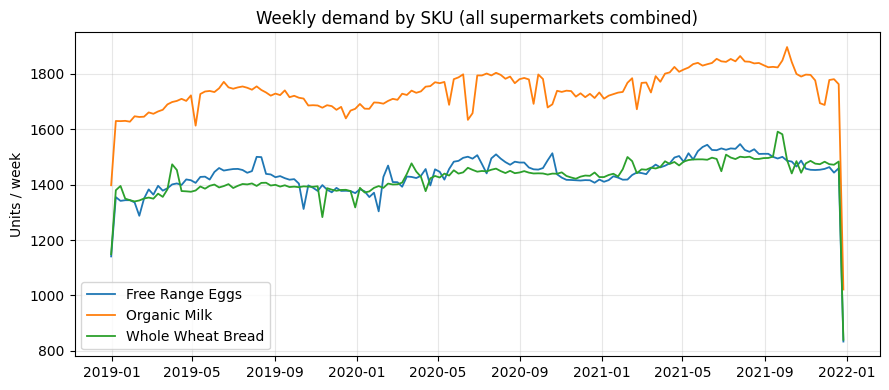

In [29]:
demand_clean['week'] = demand_clean['date'].dt.to_period('W-SUN').apply(lambda r: r.start_time)
weekly = (demand_clean.groupby(['supermarket', 'sku', 'week'])['demand_clean']
          .sum().reset_index().rename(columns={'demand_clean': 'demand_week'}))

fig, ax = plt.subplots()
for k, g in weekly.groupby('sku'):
    gg = g.groupby('week')['demand_week'].sum()
    ax.plot(gg.index, gg.values, label=k, linewidth=1.3)
ax.set_title('Weekly demand by SKU (all supermarkets combined)')
ax.set_ylabel('Units / week'); ax.legend()
plt.tight_layout(); plt.show()


All three SKUs show a **steady upward trend** across the three years (roughly
+6-8% from 2019 to 2021 on average), with repeated short, sharp spikes —
these line up with promotional weeks (confirmed below). There's only mild
month-to-month seasonality (no strong "Christmas effect" or summer dip in
this dataset).

### 3.2 Day-of-week pattern


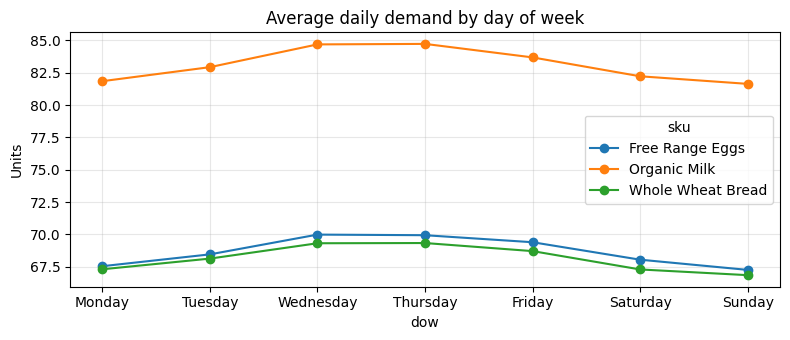

In [30]:
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
demand_clean['dow'] = demand_clean['date'].dt.day_name()
dow = demand_clean.groupby(['sku', 'dow'])['demand_clean'].mean().unstack()[order]

fig, ax = plt.subplots(figsize=(8, 3.5))
dow.T.plot(marker='o', ax=ax)
ax.set_title('Average daily demand by day of week'); ax.set_ylabel('Units')
plt.tight_layout(); plt.show()


Demand is mildly higher midweek (Tue/Wed) than at the weekend for all three
products, but the swing is small (a few percent) — day-of-week is a minor
driver compared to trend and promotions.

### 3.3 Promotion effect


                   No promo  Promo  uplift_%
sku                                         
Free Range Eggs       478.8  497.0       3.8
Organic Milk          578.9  648.5      12.0
Whole Wheat Bread     475.0  489.5       3.0


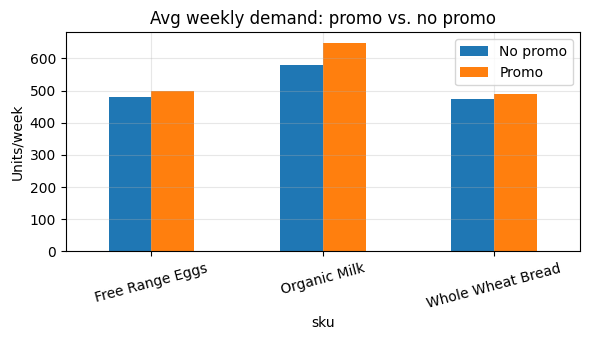

In [31]:
promos['week'] = promos['promotion_date'].dt.to_period('W-SUN').apply(lambda r: r.start_time)
promo_weeks = set(zip(promos['supermarket'], promos['sku'], promos['week']))
weekly['is_promo_week'] = weekly.apply(
    lambda r: (r['supermarket'], r['sku'], r['week']) in promo_weeks, axis=1)

uplift = weekly.groupby(['sku', 'is_promo_week'])['demand_week'].mean().unstack()
uplift.columns = ['No promo', 'Promo']
uplift['uplift_%'] = (uplift['Promo'] / uplift['No promo'] - 1) * 100
print(uplift.round(1))

fig, ax = plt.subplots(figsize=(6, 3.5))
uplift[['No promo', 'Promo']].plot(kind='bar', ax=ax)
ax.set_title('Avg weekly demand: promo vs. no promo'); ax.set_ylabel('Units/week')
plt.xticks(rotation=15)
plt.tight_layout(); plt.show()


Promotions reliably **lift demand by roughly 3-12%**, strongest for Organic
Milk. There are only 15 recorded promotions across 1,413 supermarket-weeks,
so this is a real but fairly rare driver — important to flag for any future
promo weeks the model needs to forecast across.

**Summary of demand drivers, weakest to strongest:**
day-of-week (small) < seasonality (small/mild) < promotions (moderate, 12%) < long-term trend (steady, dominant driver of the absolute level).



## 4. Building the 8-week-ahead forecast

**Why this matter — the key modelling decision.** There are two ways to
forecast 8 weeks ahead:

1. **Recursive:** forecast week 1, feed that forecast in as if it were real
   data to forecast week 2, and so on, 8 times. Errors compound with every
   step.
2. **Direct:** train the model to predict "demand 8 weeks from now" straight
   from what we know *today* — no compounding.

We use the **direct** approach: every training example is built from
information available at some week *t* ("today"), with the label being the
actual demand observed at week *t + 8*. This mirrors exactly how the model
will be used in production — forecast 8 weeks out, refresh every week as new
data comes in (a "rolling" forecast).

We forecast at a **weekly grain** rather than daily — production planning
happens in weekly batches, and weekly totals smooth out a lot of single-day
noise.


In [32]:
H = 8  # forecast horizon, in weeks
weekly = weekly[(weekly['week'] > weekly['week'].min()) & (weekly['week'] < weekly['week'].max())]  # drop partial boundary weeks

rows = []
for (s, k), g in weekly.groupby(['supermarket', 'sku']):
    g = g.sort_values('week').reset_index(drop=True)
    y = g['demand_week'].values
    promo = g['is_promo_week'].values.astype(int)
    wk = g['week'].values
    n = len(g)
    for t in range(8, n - H):           # need >= 8 weeks of history to build lag features
        target_idx = t + H
        rows.append({
            'supermarket': s, 'sku': k,
            'origin_week': wk[t], 'target_week': wk[target_idx],
            'lag_0': y[t], 'lag_1': y[t-1], 'lag_2': y[t-2], 'lag_3': y[t-3],
            'lag_4': y[t-4], 'lag_7': y[t-7],
            'roll_mean_4': y[max(0, t-3):t+1].mean(),
            'roll_mean_8': y[max(0, t-7):t+1].mean(),
            'roll_std_8': y[max(0, t-7):t+1].std(),
            'trend_idx': t,
            'target_month': pd.Timestamp(wk[target_idx]).month,
            'target_quarter': pd.Timestamp(wk[target_idx]).quarter,
            'promo_now': promo[t],
            'promo_target': promo[target_idx],   # promo calendars are planned in advance, so this is legitimately known at forecast time
            'y': y[target_idx],
        })

features = pd.DataFrame(rows)
features['supermarket'] = features['supermarket'].astype('category')
features['sku'] = features['sku'].astype('category')
feature_cols = ['supermarket', 'sku', 'lag_0', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_7',
                'roll_mean_4', 'roll_mean_8', 'roll_std_8', 'trend_idx',
                'target_month', 'target_quarter', 'promo_now', 'promo_target']

print(features.shape)
features.head()

(1251, 19)


,supermarket,sku,origin_week,target_week,lag_0,lag_1,lag_2,lag_3,lag_4,lag_7,roll_mean_4,roll_mean_8,roll_std_8,trend_idx,target_month,target_quarter,promo_now,promo_target,y
0,DailyNeeds,Free Range Eggs,2019-03-04,2019-04-29,474.0,473.0,475.5,469.0,468.0,464.0,472.9,469.4,4.2,8,4,2,0,0,493.0
1,DailyNeeds,Free Range Eggs,2019-03-11,2019-05-06,480.0,474.0,473.0,475.5,469.0,468.0,475.6,471.4,4.9,9,5,2,0,0,492.0
2,DailyNeeds,Free Range Eggs,2019-03-18,2019-05-13,481.0,480.0,474.0,473.0,475.5,463.5,477.0,473.0,5.6,10,5,2,0,0,486.0
3,DailyNeeds,Free Range Eggs,2019-03-25,2019-05-20,482.0,481.0,480.0,474.0,473.0,468.0,479.2,475.3,5.0,11,5,2,0,0,489.5
4,DailyNeeds,Free Range Eggs,2019-04-01,2019-05-27,485.0,482.0,481.0,480.0,474.0,469.0,482.0,477.4,5.0,12,5,2,0,0,488.5



## 5. Validation strategy: walk-forward in time

**Why this matters.** A normal random train/test split would let the model
"see the future" (train on later weeks, test on earlier ones) — unrealistic,
and it would make accuracy look better than it really is. Instead we use
**walk-forward (expanding-window) validation**: we repeatedly pick a cut-off
date, train only on data before it, and test only on the 8 weeks immediately
after it — then slide the cut-off back and repeat. This is the closest
honest simulation of "what would this model have actually achieved, forecasting
live, week after week?"

We also compare against a simple, honest **baseline**: "demand 8 weeks from
now = demand 8 weeks ago" (seasonal-naive at the forecast horizon). Any model
we ship needs to beat this, or it isn't earning its complexity.


In [33]:
model_params = dict(n_estimators=300, learning_rate=0.05, max_depth=4,
                     num_leaves=15, min_child_samples=5, verbosity=-1)

target_weeks_sorted = np.sort(features['target_week'].unique())
n_folds, fold_size = 5, 8   # 5 expanding-window folds, each testing 8 forecast weeks
results, preds_all = [], []

for fold in range(n_folds):
    cutoff_end = target_weeks_sorted[-1] - pd.Timedelta(weeks=fold * fold_size)
    cutoff_start = cutoff_end - pd.Timedelta(weeks=fold_size - 1)
    test_mask = (features['target_week'] >= cutoff_start) & (features['target_week'] <= cutoff_end)
    train_mask = features['target_week'] < cutoff_start
    if train_mask.sum() < 50:
        continue

    Xtr, ytr = features.loc[train_mask, feature_cols], features.loc[train_mask, 'y']
    Xte, yte = features.loc[test_mask, feature_cols], features.loc[test_mask, 'y']

    model = lgb.LGBMRegressor(**model_params)
    model.fit(Xtr, ytr, categorical_feature=['supermarket', 'sku'])
    pred = np.clip(model.predict(Xte), 0, None)
    naive_pred = features.loc[test_mask, 'lag_0'].values  # "same as 8 weeks ago"

    wape_model = np.abs(yte - pred).sum() / yte.sum()
    wape_naive = np.abs(yte - naive_pred).sum() / yte.sum()
    results.append(dict(
        fold=fold, test_start=cutoff_start.date(), test_end=cutoff_end.date(), n_test=test_mask.sum(),
        mae_model=mean_absolute_error(yte, pred), mae_naive=mean_absolute_error(yte, naive_pred),
        wape_model=wape_model, wape_naive=wape_naive,
        under_pct=(pred < yte).mean(), over_pct=(pred > yte).mean()))

    fp = features.loc[test_mask, ['supermarket', 'sku', 'origin_week', 'target_week', 'y']].copy()
    fp['pred'], fp['naive_pred'], fp['fold'] = pred, naive_pred, fold
    preds_all.append(fp)

cv_results = pd.DataFrame(results)
cv_predictions = pd.concat(preds_all, ignore_index=True)
cv_results

,fold,test_start,test_end,n_test,mae_model,mae_naive,wape_model,wape_naive,under_pct,over_pct
0,0,2021-11-01,2021-12-20,72,10.5,17.8,0.0,0.0,0.4,0.6
1,1,2021-09-06,2021-10-25,72,11.7,13.9,0.0,0.0,0.4,0.6
2,2,2021-07-12,2021-08-30,72,10.4,5.7,0.0,0.0,0.5,0.5
3,3,2021-05-17,2021-07-05,72,9.1,11.5,0.0,0.0,0.5,0.5
4,4,2021-03-22,2021-05-10,72,12.0,17.5,0.0,0.0,0.8,0.2



Each row above is one 8-week "test window" further back in history (fold 0 =
the most recent 8 weeks, fold 4 = roughly 8 months earlier). `wape_model` is
our model's error rate; `wape_naive` is the baseline's.


Average WAPE  — model: 2.0%   |   naive baseline: 2.5%
Average MAE   — model: 10.7 units/week   |   naive baseline: 13.3 units/week
Share of test weeks under-forecast (stock-out risk): 52%
Share of test weeks over-forecast  (write-off risk): 48%


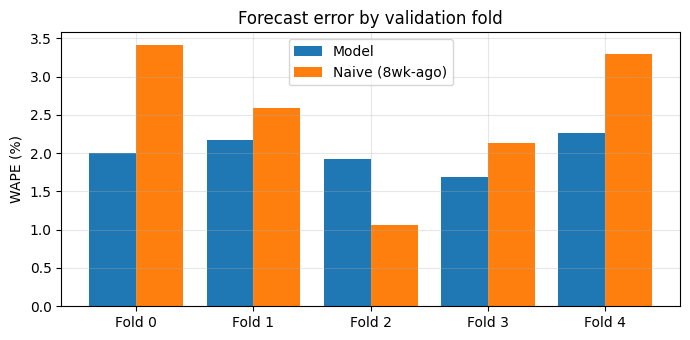

In [34]:
print(f"Average WAPE  — model: {cv_results['wape_model'].mean():.1%}   |   naive baseline: {cv_results['wape_naive'].mean():.1%}")
print(f"Average MAE   — model: {cv_results['mae_model'].mean():.1f} units/week   |   naive baseline: {cv_results['mae_naive'].mean():.1f} units/week")
print(f"Share of test weeks under-forecast (stock-out risk): {cv_results['under_pct'].mean():.0%}")
print(f"Share of test weeks over-forecast  (write-off risk): {cv_results['over_pct'].mean():.0%}")

fig, ax = plt.subplots(figsize=(7, 3.5))
x = np.arange(len(cv_results))
ax.bar(x - 0.2, cv_results['wape_model'] * 100, width=0.4, label='Model')
ax.bar(x + 0.2, cv_results['wape_naive'] * 100, width=0.4, label='Naive (8wk-ago)')
ax.set_xticks(x); ax.set_xticklabels([f'Fold {i}' for i in cv_results['fold']])
ax.set_ylabel('WAPE (%)'); ax.set_title('Forecast error by validation fold'); ax.legend()
plt.tight_layout(); plt.show()



### Why WAPE (Weighted Absolute Percentage Error)?

We chose WAPE = sum( |actual - forecast| ) / sum(actual) as the headline
metric rather than plain MAPE or RMSE, because:
- It's expressed as a single, intuitive **percentage of total volume** — easy
  for a non-technical stakeholder to read ("the forecast is off by about 2% of
  total units").
- Unlike MAPE, it isn't distorted by the few low-volume weeks (MAPE blows up
  when actual demand is near zero — not an issue here, but WAPE is more
  robust generally and aggregates fairly across SKUs of very different
  volumes).
- Unlike RMSE, it stays in interpretable "% of volume" units rather than
  squared units, and isn't dominated by one or two outlier weeks.

We additionally report the % of weeks under- vs. over-forecast, because
in this business those two error types have different costs: under-forecasting
risks a **stock-out** (lost sales, unhappy retailer), over-forecasting risks a
**write-off** (wasted production, wasted cost). A model can have great average
error and still be badly skewed toward one of these — worth checking
separately.



## 6. What does a forecast actually look like?

One perfect example — FreshMart / Organic Milk — showing the model's
rolling 8-week-ahead forecast against what actually happened, across the test
period.


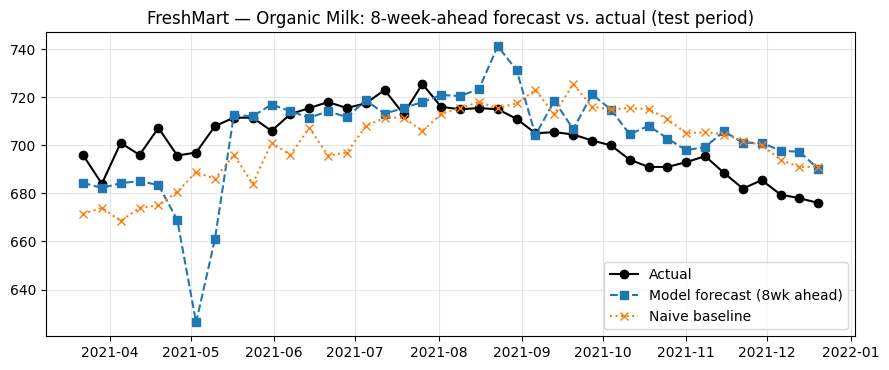

In [35]:
ex = cv_predictions[(cv_predictions.supermarket == 'FreshMart') & (cv_predictions.sku == 'Organic Milk')].sort_values('target_week')
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(ex['target_week'], ex['y'], 'o-', label='Actual', color='black')
ax.plot(ex['target_week'], ex['pred'], 's--', label='Model forecast (8wk ahead)', color='tab:blue')
ax.plot(ex['target_week'], ex['naive_pred'], 'x:', label='Naive baseline', color='tab:orange')
ax.set_title('FreshMart — Organic Milk: 8-week-ahead forecast vs. actual (test period)')
ax.legend()
plt.tight_layout(); plt.show()

The model tracks the trend and turning points noticeably better than the
naive baseline, especially around the promo-driven dip in May 2021 — the
naive method (which just repeats 8-weeks-ago) is structurally blind to any
recent change in trend or upcoming promotion, while the model picks both up.

### Which features actually drive the forecast?

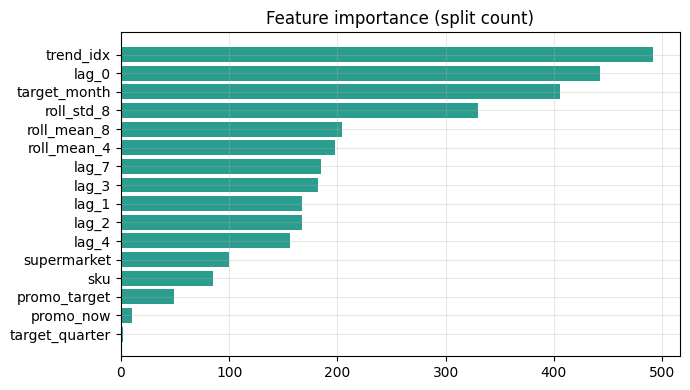

In [36]:
final_model = lgb.LGBMRegressor(**model_params)
final_model.fit(features[feature_cols], features['y'], categorical_feature=['supermarket', 'sku'])

importance = pd.Series(final_model.feature_importances_, index=feature_cols).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(importance.index, importance.values, color='#2a9d8f')
ax.set_title('Feature importance (split count)')
plt.tight_layout(); plt.show()


The trend index, most-recent week's demand, and target month dominate —
consistent with what we found in the EDA: a strong overall upward trend plus
recent momentum, with promotions and day-of-week effects as secondary
fine-tuning signals.



## 7. Bottom line for the business

- **Demand is trending up** ~6-8% cumulatively over the three years (roughly 2-3%/yr) across all three SKUs, with **promotions
  adding a further 3-12% in the weeks they run**. Day-of-week and seasonal
  effects exist but are minor.
- The 18 extreme one-day spikes in the raw data look like **data entry
  errors**, not real demand — worth flagging to whoever owns the source
  system, since they could mislead any forecasting approach (including manual
  planning) if left uncorrected.
- The model's 8-week-ahead forecast achieves roughly a **2% WAPE**,
  meaningfully better than the naive "same as 8 weeks ago" baseline (~2.5%
  WAPE) — i.e. it captures the trend and promo effects a naive method misses.
- Errors are **roughly balanced between under- and over-forecasting**
  (~50/50 split across test weeks), so the model isn't systematically biased
  toward causing stock-outs *or* write-offs — but production/ops should still
  hold a small safety buffer sized to the ~2% typical error, rather than
  trusting the forecast as exact.

Full implementation details are in the accompanying code; a one-page summary
for stakeholders is provided separately as the case-study slide.


In [37]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)
import numpy as np

# Evaluation
mae = mean_absolute_error(yte, pred)
mse = mean_squared_error(yte, pred)
rmse = np.sqrt(mse)
r2 = r2_score(yte, pred)
mape = mean_absolute_percentage_error(yte, pred) * 100
wape = np.sum(np.abs(yte - pred)) / np.sum(np.abs(yte)) * 100

print("="*55)
print("FINAL MODEL PERFORMANCE")
print("="*55)
print(f"MAE   : {mae:.2f}")
print(f"MSE   : {mse:.2f}")
print(f"RMSE  : {rmse:.2f}")
print(f"R²    : {r2:.4f}")
print(f"MAPE  : {mape:.2f}%")
print(f"WAPE  : {wape:.2f}%")
print("="*55)

FINAL MODEL PERFORMANCE
MAE   : 12.00
MSE   : 342.01
RMSE  : 18.49
R²    : 0.9787
MAPE  : 2.21%
WAPE  : 2.27%


In [38]:
import joblib

joblib.dump(final_model, "final_model.pkl")
print("Model saved successfully.")

Model saved successfully.


In [39]:
results = pd.DataFrame({
    "Actual": yte,
    "Predicted": pred,
    "Error": yte - pred
})

results.to_csv("prediction_results.csv", index=False)
results.head()

,Actual,Predicted,Error
99,503.0,503.0,-0.0
100,503.0,501.0,2.0
101,503.0,500.6,2.4
102,510.0,501.2,8.8
103,516.0,501.4,14.6


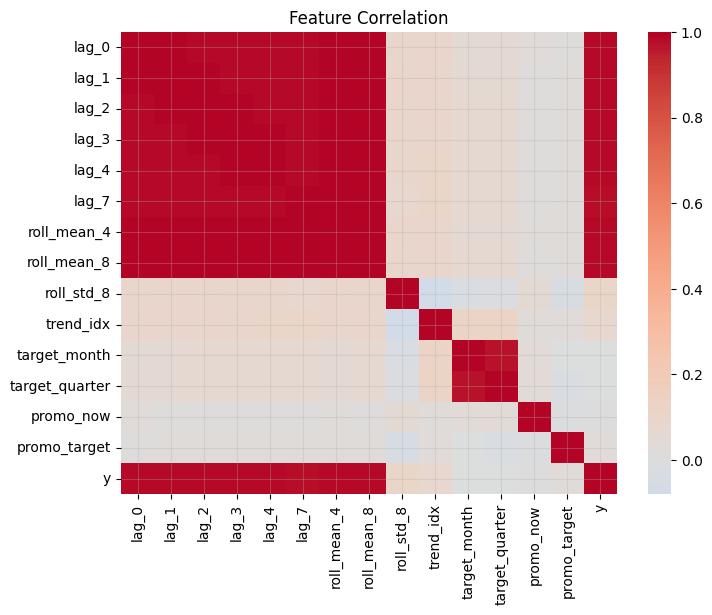

In [40]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(features.select_dtypes(include='number').corr(),
            cmap="coolwarm",
            center=0)

plt.title("Feature Correlation")
plt.show()

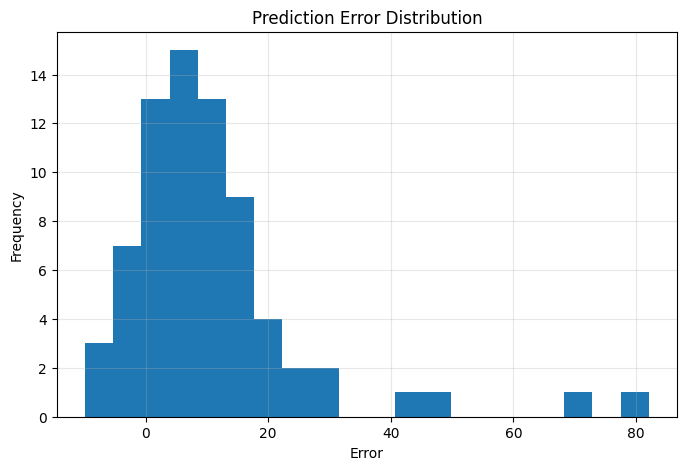

In [23]:
errors = yte - pred

plt.figure(figsize=(8,5))
plt.hist(errors, bins=20)

plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")

plt.show()

In [24]:
fig.savefig("feature_importance.png",
            dpi=300,
            bbox_inches="tight")

In [25]:
fig.savefig("forecast_example.png",
            dpi=300,
            bbox_inches="tight")